# Women's E-Commerce Clothing Reviews


## Dataset Overview

This dataset contains **23,486 customer reviews** with **10 features** per review.

## Feature Description

| Variable | Type | Description |
|----------|------|-------------|
| **Clothing ID** | Integer (Categorical) | Unique identifier for the specific clothing item being reviewed |
| **Age** | Positive Integer | Age of the reviewer |
| **Title** | String | Title of the review |
| **Review Text** | String | Main body/content of the review |
| **Rating** | Positive Ordinal Integer (1-5) | Product rating where 1 = Worst, 5 = Best |
| **Recommended IND** | Binary (0/1) | Recommendation indicator: 1 = Recommended, 0 = Not Recommended |
| **Positive Feedback Count** | Positive Integer | Number of other customers who found this review helpful |
| **Division Name** | Categorical | High-level product division category |
| **Department Name** | Categorical | Product department category |
| **Class Name** | Categorical | Specific product class/category |

## Basic Stack

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Loading dataset 

In [4]:
url = "https://raw.githubusercontent.com/jhlopesalves/data-science-notebooks/refs/heads/main/Python/projects/womens_ecommerce/data/Womens%20Clothing%20E-Commerce%20Reviews.csv"
womens = pd.read_csv(url, usecols=lambda col: not col.startswith("Unnamed"))

## Basic EDA (inspection)

In [5]:
womens

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...
23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


In [6]:
womens.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended IND          23486 non-null  int64 
 6   Positive Feedback Count  23486 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 1.8+ MB


In [8]:
womens[["Age", "Rating", "Positive Feedback Count"]].describe()

,Age,Rating,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000
mean,43.198544,4.196032,2.535936
std,12.279544,1.110031,5.702202
min,18.000000,1.000000,0.000000
25%,34.000000,4.000000,0.000000
50%,41.000000,5.000000,1.000000
75%,52.000000,5.000000,3.000000
max,99.000000,5.000000,122.000000


In [10]:
sns.set_color_codes("bright")

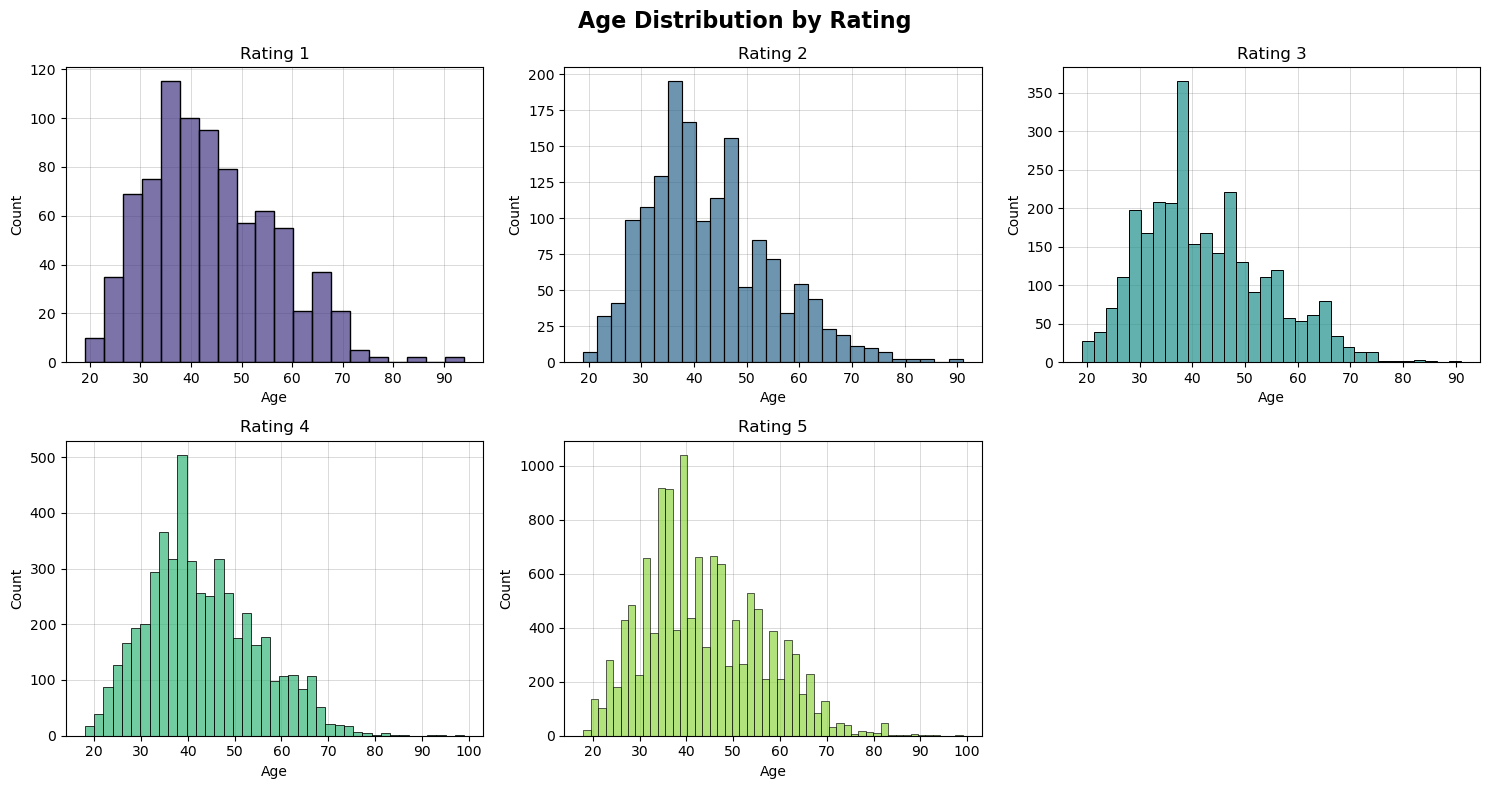

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, rating in enumerate(sorted(womens["Rating"].unique())):
    sns.histplot(
        data=womens[womens["Rating"] == rating],
        x="Age",
        ax=axes[i],
        color=sns.color_palette("viridis", 5)[i],
        alpha=0.7,
    )
    axes[i].set_title(f"Rating {rating}")
    axes[i].grid(True, alpha=0.4, linewidth=0.5, color="grey")
    axes[i].set_axisbelow(True)

fig.delaxes(axes[5])

# Add overall title
fig.suptitle("Age Distribution by Rating", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()